In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np


In [2]:
df = pd.read_csv('../paper_comparison.csv')

In [3]:
df.columns

Index(['Paper', 'Number of patients in dataset', 'Pre training dataset',
       'Model', 'Model input', 'Model output', 'Results', 'Limitations',
       'Framework', 'Preprocessing and data augmentation',
       'Variability in results', 'Dataset availability'],
      dtype='str')

In [4]:
df = df.drop(columns=['Preprocessing and data augmentation', 'Results', 'Framework'])

res = df.to_latex()

In [5]:
print(res)

\begin{tabular}{llrlllllll}
\toprule
 & Paper & Number of patients in dataset & Pre training dataset & Model & Model input & Model output & Limitations & Variability in results & Dataset availability \\
\midrule
0 & Zhao et al. (2024) & 1654 & Not specified & encoder-decoder prediction head & 2D TVUS & Classification & Using static images instead of dynamic & no & – \\
1 & Raimondo et al. (2023) & 100 & Microsoft Common Objects & VGG13 & VGG19 & ResNet18 & ResNet34 & 2D TVUS images extracted from video clips & Classification & Small sample size & monocentric & yes & yes* \\
2 & Tank et al. (2025) & 124 & – & U-Net & nnU-Net & 2D TVUS & Segmentation & Small sample size & monocentric & yes & yes* \\
3 & Bones et al. (2024) & 298 & Swin pretrained on CT data & nnU-Net & Swin UNETR & 3D TVUS & Segmentation & – & no & yes \\
4 & Zhao et al. (2023) & 4401 & ImageNet & VGG16 & InceptionV3 & ResNet50 & ResNet101 & 2D cross-sectional images from 3D TVUS & Classification & Not using full 3D TVUS

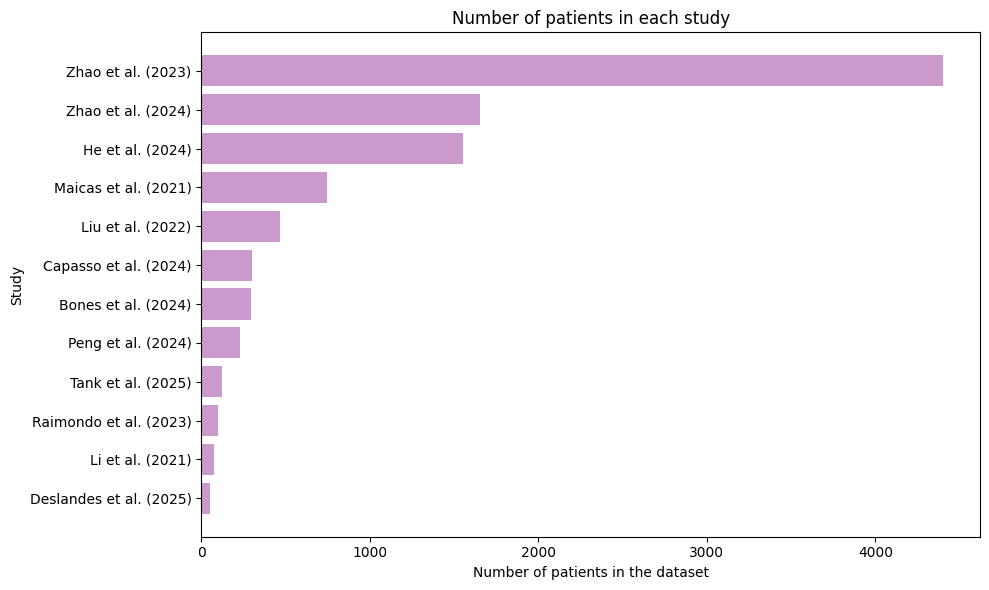

Mean number of patients: 833.6666666666666
Median number of patients: 300.0


In [6]:

df = pd.read_csv("../paper_comparison.csv")

df_sorted = df.sort_values("Number of patients in dataset", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_sorted["Paper"], df_sorted["Number of patients in dataset"], color="purple", alpha=0.4)
plt.xlabel("Number of patients in the dataset")
plt.ylabel("Study")
plt.title("Number of patients in each study")
plt.tight_layout()
plt.show()

print("Mean number of patients:", df["Number of patients in dataset"].mean())
print("Median number of patients:", df["Number of patients in dataset"].median())



In [7]:
df["Publication year"] = df["Paper"].str.extract(r"\((\d{4})\)")
df["Publication year"] = pd.to_numeric(df["Publication year"], errors="coerce")
print("Average publication year:", df["Publication year"].mean())
print("Average publication year:", df["Publication year"].median())

Average publication year: 2023.3333333333333
Average publication year: 2024.0


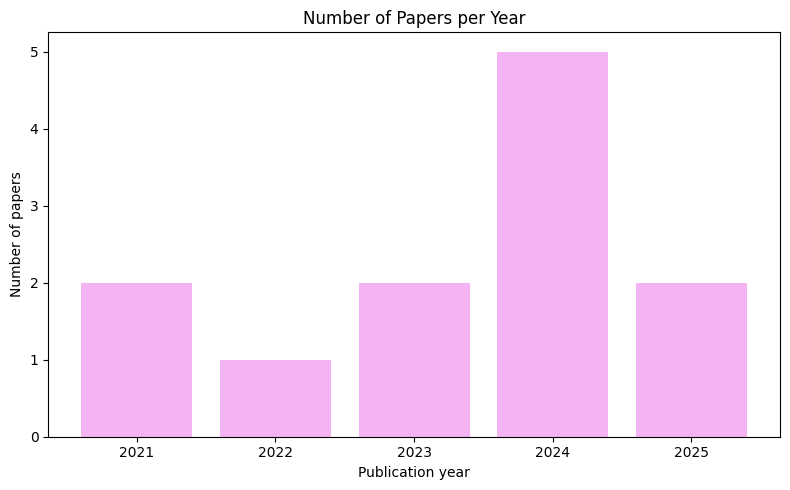

In [8]:
year_counts = Counter(df["Publication year"])

sorted_years = sorted(year_counts.keys())
counts = [year_counts[year] for year in sorted_years]

plt.style.use("default")

plt.figure(figsize=(8, 5))
plt.bar(sorted_years, counts, color='violet', alpha=0.6)

plt.xlabel("Publication year")
plt.ylabel("Number of papers")
plt.title("Number of Papers per Year")
plt.xticks(sorted_years)

plt.tight_layout()
plt.show()

In [9]:
df["Publication year"] = df["Publication year"].astype(float)
df.loc[3, "Publication year"] += 0.1
df.loc[0, "Publication year"] += 0.1
df.loc[6, "Publication year"] += 0.2
df.loc[7, "Publication year"] += 0.1

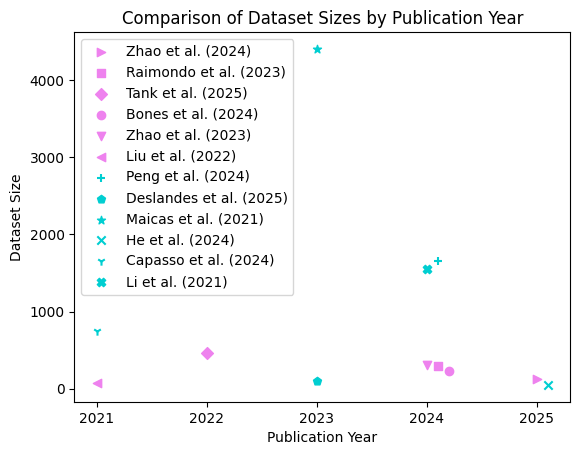

In [10]:

markers = ['>', 's', 'D', 'o', 'v', '<', '+', 'p', '*', 'x', '1', 'X']

# sort df by Model output to ensure consistent coloring
df_sorted = df.sort_values("Model output", ascending=False).reset_index(drop=True)

for i, (x, y) in enumerate(zip(df_sorted["Publication year"], df_sorted["Number of patients in dataset"])):
    label = 'Segmentation' if df_sorted["Model output"].iloc[i] == "Segmentation" else 'Classification'
    color = 'violet' if label == 'Segmentation' else 'darkturquoise'
    plt.scatter(x, y, color=color, label=label, marker=markers[i])

plt.xlabel("Publication Year")
plt.ylabel("Dataset Size")
plt.title("Comparison of Dataset Sizes by Publication Year")
plt.legend(df['Paper'])
plt.show()




In [ ]:
seg_avg_patients = df[df["Model output"] == "Segmentation"]["Number of patients in dataset"].mean()
class_avg_patients = df[df["Model output"] == "Classification"]["Number of patients in dataset"].mean()
print("Average number of patients for Segmentation papers:", seg_avg_patients)
print("Average number of patients for Classification papers:", class_avg_patients)
avg_patients = df["Number of patients in dataset"].mean()
print("Average number of patients across all papers:", avg_patients)


# median
seg_median_patients = df[df["Model output"] == "Segmentation"]["Number of patients in dataset"].median()
class_median_patients = df[df["Model output"] == "Classification"]["Number of patients in dataset"].median()
print("Median number of patients for Segmentation papers:", seg_median_patients)
print("Median number of patients for Classification papers:", class_median_patients)
median_patients = df["Number of patients in dataset"].median()
print("Median number of patients across all papers:", median_patients)


Average number of patients for Segmentation papers: 249.16666666666666
Average number of patients for Classification papers: 1418.1666666666667
Average number of patients across all papers: 833.6666666666666
Median number of patients for Segmentation papers: 263.5
Median number of patients for Classification papers: 1152.0
Median number of patients across all papers: 300.0
